In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from tools import load_data

## Impact between: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$ and $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

How exactly is it possible to determine the force $F$ at different positions $A$?

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for {target} and a tolerance of {tol}.")
    return detected

In [4]:
target_A_names = [20, 40, 60, 80]  # °
tol = 1

targets_A = {}
for tns in target_A_names:
    ps = indices_with_tolerance(A, tns, tol)  # Adjustment place
    np.random.shuffle(ps)
    targets_A[tns] = ps
y_label_A = [f"{tns}$\pm${tol}°" for tns in target_A_names]  # Adjustment place

Found 1,043 for 20 and a tolerance of 1.
Found 1,049 for 40 and a tolerance of 1.
Found 1,039 for 60 and a tolerance of 1.
Found 1,067 for 80 and a tolerance of 1.


In [5]:
targets_A

{20: array([40936, 41309,  1025, ..., 33242, 53782, 17418], shape=(1043,)),
 40: array([49493,  9273, 67275, ..., 46726, 25694, 27705], shape=(1049,)),
 60: array([ 7597,  4095, 34906, ..., 24844, 48826, 64705], shape=(1039,)),
 80: array([45436, 13696, 48773, ..., 46925,  3420, 27254], shape=(1067,))}

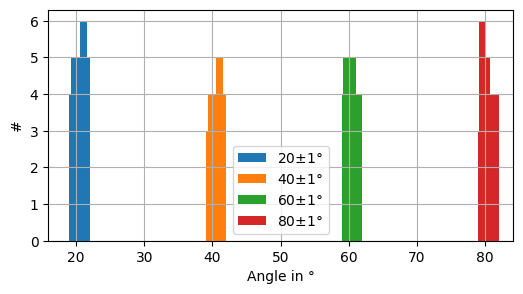

In [6]:
plt.figure(figsize=(6, 3))
for tars_kys, tars_vls in targets_A.items():
    plt.hist(
        A[tars_vls], bins=len(A[tars_vls]), label=tars_kys, align="mid", width=1
    )  # Adjustment place
plt.grid()
plt.legend(y_label_A)
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
target_F_names = [50, 75, 100, 125, 150, 175, 200]

tol = 5
targets_F = {}
for tns in target_F_names:
    ps = indices_with_tolerance(F, tns, tol)  # Adjustment place
    np.random.shuffle(ps)
    targets_F[tns] = ps
y_label_F = [f"{tns}$\pm${tol}N" for tns in target_F_names]  # Adjustment place

Found 2,905 for 50 and a tolerance of 5.
Found 4,064 for 75 and a tolerance of 5.
Found 3,584 for 100 and a tolerance of 5.
Found 3,629 for 125 and a tolerance of 5.
Found 3,079 for 150 and a tolerance of 5.
Found 2,400 for 175 and a tolerance of 5.
Found 2,244 for 200 and a tolerance of 5.


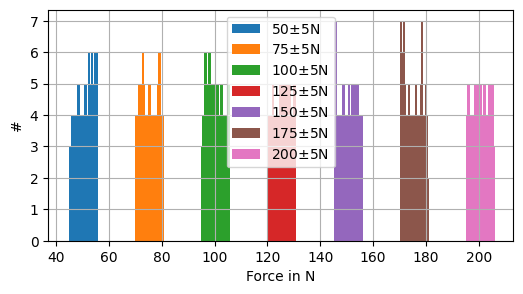

In [8]:
plt.figure(figsize=(6, 3))
for tars_kys, tars_vls in targets_F.items():
    plt.hist(
        F[tars_vls], bins=len(F[tars_vls]), label=tars_kys, align="mid", width=1
    )  # Adjustment place
plt.grid()
plt.legend(y_label_F)
plt.ylabel("#")
plt.xlabel("Force in N")  # Adjustment place
plt.show()

**Evaluate force $F$ at discrete angles $A$**

In [13]:
params_path = "params/TrainValid_F_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)

best_model = RandomForestClassifier(**best_params_)  # Adjustment place
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Loaded params


In [14]:
SCORES = []
R2 = []
for tars_kys, tars_vls in targets_A.items():
    print(f"Discrete target angle: {tars_kys}°")
    XA = X[tars_vls]
    FA = F[tars_vls]
    PA = P[tars_vls]
    # test the classification ability for Force at the corresponding angle
    targets = np.concatenate(
        [indices_with_tolerance(FA, tF, tol) for tF in targets_F.keys()]
    )
    np.random.shuffle(targets)

    y = FA[targets]  # F -> Force # Adjustment place
    EIT = XA[targets]
    Pwise = PA[targets]

    y_cont = y.reshape(-1, 1)
    binning = KBinsDiscretizer(
        n_bins=3,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf",
    )
    y = binning.fit_transform(y_cont).ravel()

    # compute force classification for specific angle

    cmy_pred = []
    cmy_true = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
        X_train, X_valid = EIT[train_idx], EIT[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_valid)

        cmy_pred.append(y_pred)
        cmy_true.append(y_valid)

        acc = balanced_accuracy_score(y_valid, y_pred)
        print(f"Fold {fold} Balanced Accuracy: {acc:.3f}")

    cmy_pred = np.concatenate(cmy_pred)
    cmy_true = np.concatenate(cmy_true)

    print(f"\naccuracy_score: {accuracy_score(cmy_true, cmy_pred):.3f}")
    print(f"balanced_accuracy_score: {balanced_accuracy_score(cmy_true, cmy_pred):.3f}")
    print(f"r2_score: {r2_score(cmy_true, cmy_pred):.3f}")
    print("----------------------------")
    SCORES.append(balanced_accuracy_score(cmy_true, cmy_pred))
    R2.append(r2_score(cmy_true, cmy_pred))

print(f"\nScores mean: {np.mean(SCORES)}")
print(f"R² mean: {np.mean(R2)}")

Discrete target angle: 20°
Found 15 for 50 and a tolerance of 5.
Found 66 for 75 and a tolerance of 5.
Found 59 for 100 and a tolerance of 5.
Found 77 for 125 and a tolerance of 5.
Found 84 for 150 and a tolerance of 5.
Found 78 for 175 and a tolerance of 5.
Found 34 for 200 and a tolerance of 5.
Fold 1 Balanced Accuracy: 0.891
Fold 2 Balanced Accuracy: 0.914
Fold 3 Balanced Accuracy: 0.952
Fold 4 Balanced Accuracy: 0.939
Fold 5 Balanced Accuracy: 0.952

accuracy_score: 0.930
balanced_accuracy_score: 0.930
r2_score: 0.796
----------------------------
Discrete target angle: 40°
Found 25 for 50 and a tolerance of 5.
Found 52 for 75 and a tolerance of 5.
Found 59 for 100 and a tolerance of 5.
Found 64 for 125 and a tolerance of 5.
Found 56 for 150 and a tolerance of 5.
Found 37 for 175 and a tolerance of 5.
Found 38 for 200 and a tolerance of 5.
Fold 1 Balanced Accuracy: 0.941
Fold 2 Balanced Accuracy: 0.848
Fold 3 Balanced Accuracy: 0.894
Fold 4 Balanced Accuracy: 0.894
Fold 5 Balanced A

**Evaluate anlge $A$ at discrete forces $F$**

In [15]:
params_path = "params/TrainValid_A_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)

best_model = RandomForestClassifier(**best_params_)  # Adjustment place
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Loaded params


In [16]:
SCORES = []
R2 = []
for tars_kys, tars_vls in targets_F.items():
    print(f"Discrete target force: {tars_kys}N")
    XF = X[tars_vls]
    AF = A[tars_vls]
    PF = P[tars_vls]
    # test the classification ability for Force at the corresponding angle
    targets = np.concatenate(
        [indices_with_tolerance(AF, tA, tol) for tA in targets_A.keys()]
    )
    np.random.shuffle(targets)
    y = AF[targets]
    EIT = XF[targets]
    Pwise = PF[targets]

    y_cont = y.reshape(-1, 1)
    binning = KBinsDiscretizer(
        n_bins=3,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf",
    )
    y = binning.fit_transform(y_cont).ravel()
    # compute force classification for specific angle

    cmy_pred = []
    cmy_true = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
        X_train, X_valid = EIT[train_idx], EIT[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_valid)

        cmy_pred.append(y_pred)
        cmy_true.append(y_valid)

        acc = balanced_accuracy_score(y_valid, y_pred)
        print(f"Fold {fold} Balanced Accuracy: {acc:.3f}")

    cmy_pred = np.concatenate(cmy_pred)
    cmy_true = np.concatenate(cmy_true)

    print(f"\naccuracy_score: {accuracy_score(cmy_true, cmy_pred):.3f}")
    print(f"balanced_accuracy_score: {balanced_accuracy_score(cmy_true, cmy_pred):.3f}")
    print(f"r2_score: {r2_score(cmy_true, cmy_pred):.3f}")
    print("----------------------------")
    SCORES.append(balanced_accuracy_score(cmy_true, cmy_pred))
    R2.append(r2_score(cmy_true, cmy_pred))

print(f"\nScores mean: {np.mean(SCORES)}")
print(f"R² mean: {np.mean(R2)}")

Discrete target force: 50N
Found 83 for 20 and a tolerance of 5.
Found 127 for 40 and a tolerance of 5.
Found 63 for 60 and a tolerance of 5.
Found 126 for 80 and a tolerance of 5.
Fold 1 Balanced Accuracy: 0.987
Fold 2 Balanced Accuracy: 0.937
Fold 3 Balanced Accuracy: 0.963
Fold 4 Balanced Accuracy: 0.913
Fold 5 Balanced Accuracy: 0.950

accuracy_score: 0.950
balanced_accuracy_score: 0.950
r2_score: 0.925
----------------------------
Discrete target force: 75N
Found 308 for 20 and a tolerance of 5.
Found 242 for 40 and a tolerance of 5.
Found 294 for 60 and a tolerance of 5.
Found 242 for 80 and a tolerance of 5.
Fold 1 Balanced Accuracy: 0.968
Fold 2 Balanced Accuracy: 0.977
Fold 3 Balanced Accuracy: 0.972
Fold 4 Balanced Accuracy: 0.981
Fold 5 Balanced Accuracy: 0.936

accuracy_score: 0.967
balanced_accuracy_score: 0.967
r2_score: 0.950
----------------------------
Discrete target force: 100N
Found 369 for 20 and a tolerance of 5.
Found 294 for 40 and a tolerance of 5.
Found 188 fo

- $R^2 = 1.0$ → perfect prediction
- $R^2 = 0.0$ → as good as predicting the mean
- $R^2 < 0.0$ → worse than predicting the mean

___